# **Importanmos los Datos, los normalizamos y extraemos lo mas importante para analizar el Churn**

In [53]:
import pandas as pd
import json

# 1. Cargar el archivo JSON

with open('TelecomX_Data.json', 'r') as file:
    datos_json = json.load(file)

# 2. Convertir a DataFrame de Pandas
# Utilizamos json_normalize para "aplanar" las columnas anidadas (customer, phone, internet, account)
df = pd.json_normalize(datos_json)

# Ver las primeras filas para confirmar la carga
print(df.head())

# Verificar la estructura de las nuevas columnas
print(df.columns)

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

# **Identificamos los tipos de datos que existen**

1. Exploración de Columnas y Tipos de Datos
El dataset TelecomX_Data.json tiene una estructura jerárquica (anidada). A continuación se detallan las variables principales y sus tipos de datos detectados:

In [48]:
# Verificar tipos de datos y valores nulos
print(df.info())

# Ver un resumen estadístico de las columnas numéricas
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## **2. Diccionario de Variables Clave**
Para comprender mejor el contexto de los datos:

**Churn:** Indica si el cliente abandonó la compañía en el último mes (Variable objetivo).

**Tenure:** Número de meses que el cliente ha permanecido en la empresa.

**Contract:** El tipo de contrato actual (Mes a mes, Un año, Dos años).

**PaperlessBilling:** Si el cliente utiliza factura electrónica.

 **SeniorCitizen:** Indica si el cliente es una persona mayor (1) o no (0).

# **3. Columnas Relevantes para el Análisis de Evasión**
Basado en la estructura del archivo, estas son las variables críticas para identificar patrones de abandono:

**Churn (Target):** Es indispensable para entrenar cualquier modelo predictivo.

**Contract: Históricamente**, los contratos "Month-to-month" (mes a mes) presentan tasas de evasión mucho más altas que los contratos a largo plazo.

**Tenure**: Permite identificar en qué mes es más probable que un cliente se dé de baja.

**TechSupport & OnlineSecurity:** La falta de estos servicios adicionales suele estar correlacionada con una mayor insatisfacción y abandono.

**Monthly Charges:** Ayuda a determinar si el precio es un factor determinante en la decisión de irse.

**PaymentMethod:** Algunos métodos (como "Electronic check") suelen estar asociados a perfiles con mayor rotación.

In [54]:
# 1. Cargar y aplanar los datos JSON
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

# Convertir la estructura anidada en una tabla plana (Dataframe)
df = pd.json_normalize(data)

# Simplificar los nombres de las columnas quitando los prefijos (ej: 'account.Charges.Total' -> 'Total')
df.columns = [col.split('.')[-1] for col in df.columns]

# 2. Eliminar clientes duplicados
df = df.drop_duplicates(subset=['customerID'])

# 3. Tratar valores ausentes en la variable objetivo 'Churn'
# Filtramos y nos quedamos solo con las filas que sí tienen un valor de Churn válido
df = df[df['Churn'] != ""]

# 4. Corregir el formato de Cargos Totales ('Total')
# Convertimos de texto a número. Aquellos errores o vacíos se transforman temporalmente en NaN (Not a Number)
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Los clientes completamente nuevos (tenure = 0) no tienen cargos totales aún, así que rellenamos los NaN con 0
df['Total'] = df['Total'].fillna(0)

# 5. Estandarizar la categoría binaria 'SeniorCitizen'
# Reemplazamos 1 y 0 por 'Yes' y 'No' para mantener consistencia con las otras columnas
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

# 6. Simplificar categorías redundantes
# Si no tienen internet, no tienen el servicio extra, por lo que equivale simplemente a un "No"
cols_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_internet:
    df[col] = df[col].replace({'No internet service': 'No'})

# Aplicamos la misma lógica para el servicio de múltiples líneas telefónicas
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

# 7. Guardar la versión limpia en un archivo CSV para la fase de entrenamiento
df.to_csv('TelecomX_Data_Clean.csv', index=False)

## **Comprobación de incoherencias en los datos**

In [67]:
df_simplified.head()

,Churn,Contract,tenure,TechSupport,OnlineSecurity,Monthly,PaymentMethod
0,0,One year,9,1,0,65.6,Mailed check
1,0,Month-to-month,9,0,0,59.9,Mailed check
2,1,Month-to-month,4,0,0,73.9,Electronic check
3,1,Month-to-month,13,0,0,98.0,Electronic check
4,1,Month-to-month,3,1,0,83.9,Mailed check


In [70]:
df_simplified.dtypes

,0
Churn,int64
Contract,object
tenure,int64
TechSupport,int64
OnlineSecurity,int64
Monthly,float64
PaymentMethod,object


In [68]:
# Definir las columnas clave para el análisis
columnas_clave = [
    'Churn',
    'Contract',
    'tenure',
    'TechSupport',
    'OnlineSecurity',
    'Monthly',
    'PaymentMethod'
]

# Crear un nuevo DataFrame con solo estas columnas
df_simplified = df[columnas_clave].copy()

# Mapear valores binarios a 0 y 1 en df_simplified
mapeo_binario = {'Yes': 1, 'No': 0}

binary_cols_to_map = ['Churn', 'TechSupport', 'OnlineSecurity']

for col in binary_cols_to_map:
    if col in df_simplified.columns and df_simplified[col].dtype == 'object':
        df_simplified[col] = df_simplified[col].map(mapeo_binario)




In [71]:
df_simplified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Churn           7043 non-null   int64  
 1   Contract        7043 non-null   object 
 2   tenure          7043 non-null   int64  
 3   TechSupport     7043 non-null   int64  
 4   OnlineSecurity  7043 non-null   int64  
 5   Monthly         7043 non-null   float64
 6   PaymentMethod   7043 non-null   object 
dtypes: float64(1), int64(4), object(2)
memory usage: 440.2+ KB


# Traducción al español y creacion de nueva columna de "cuentas diarias" **texto en negrita**

In [73]:
# 1. Agregar 'Cuentas_Diarias' directamente a df_simplified (corrigiendo el paso anterior)
df_simplified['Cuentas_Diarias'] = (df_simplified['Monthly'] / 30).round(2)

# 2. Diccionario para renombrar tus 7 columnas clave
diccionario_columnas = {
    'Churn': 'Evasion',
    'Contract': 'Contrato',
    'tenure': 'Permanencia_Meses',
    'TechSupport': 'Soporte_Tecnico',
    'OnlineSecurity': 'Seguridad_En_Linea',
    'Monthly': 'Cargo_Mensual',
    'PaymentMethod': 'Metodo_Pago'
}

# Aplicar el renombramiento de columnas
df_simplified = df_simplified.rename(columns=diccionario_columnas)

# 3. Diccionarios para traducir los valores categóricos (los que siguen siendo texto 'object')
# Nota: Ya no traducimos 'Yes'/'No' porque excelentemente ya los pasaste a 1 y 0.
traduccion_contrato = {
    'Month-to-month': 'Mes a mes',
    'One year': 'Un año',
    'Two year': 'Dos años'
}
traduccion_pago = {
    'Electronic check': 'Cheque electronico',
    'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria',
    'Credit card (automatic)': 'Tarjeta de credito'
}

# 4. Aplicar la traducción a los datos de las columnas
df_simplified['Contrato'] = df_simplified['Contrato'].replace(traduccion_contrato)
df_simplified['Metodo_Pago'] = df_simplified['Metodo_Pago'].replace(traduccion_pago)

# 5. Comprobar los resultados finales
print("--- Primeras filas de df_simplified en Español ---")
display(df_simplified.head())

print("\n--- Tipos de datos listos para el EDA ---")
print(df_simplified.dtypes)

--- Primeras filas de df_simplified en Español ---


,Evasion,Contrato,Permanencia_Meses,Soporte_Tecnico,Seguridad_En_Linea,Cargo_Mensual,Metodo_Pago,Cuentas_Diarias
0,0,Un año,9,1,0,65.6,Cheque por correo,2.19
1,0,Mes a mes,9,0,0,59.9,Cheque por correo,2.00
2,1,Mes a mes,4,0,0,73.9,Cheque electronico,2.46
3,1,Mes a mes,13,0,0,98.0,Cheque electronico,3.27
4,1,Mes a mes,3,1,0,83.9,Cheque por correo,2.80



--- Tipos de datos listos para el EDA ---
Evasion                 int64
Contrato               object
Permanencia_Meses       int64
Soporte_Tecnico         int64
Seguridad_En_Linea      int64
Cargo_Mensual         float64
Metodo_Pago            object
Cuentas_Diarias       float64
dtype: object


# **Distribución de evasión**

In [74]:
# 1. Análisis descriptivo de las variables numéricas y binarias (0 y 1)
print("--- Estadísticas Descriptivas (Numéricas) ---")
display(df_simplified.describe().round(2))

# 2. Análisis descriptivo de las variables categóricas (texto)
print("\n--- Estadísticas Descriptivas (Categóricas) ---")
display(df_simplified.describe(include=['object']))

--- Estadísticas Descriptivas (Numéricas) ---


,Evasion,Permanencia_Meses,Soporte_Tecnico,Seguridad_En_Linea,Cargo_Mensual,Cuentas_Diarias
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.27,32.37,0.29,0.29,64.76,2.16
std,0.44,24.56,0.45,0.45,30.09,1.00
min,0.00,0.00,0.00,0.00,18.25,0.61
25%,0.00,9.00,0.00,0.00,35.50,1.18
50%,0.00,29.00,0.00,0.00,70.35,2.34
75%,1.00,55.00,1.00,1.00,89.85,2.99
max,1.00,72.00,1.00,1.00,118.75,3.96



--- Estadísticas Descriptivas (Categóricas) ---


,Contrato,Metodo_Pago
count,7043,7043
unique,3,4
top,Mes a mes,Cheque electronico
freq,3875,2365


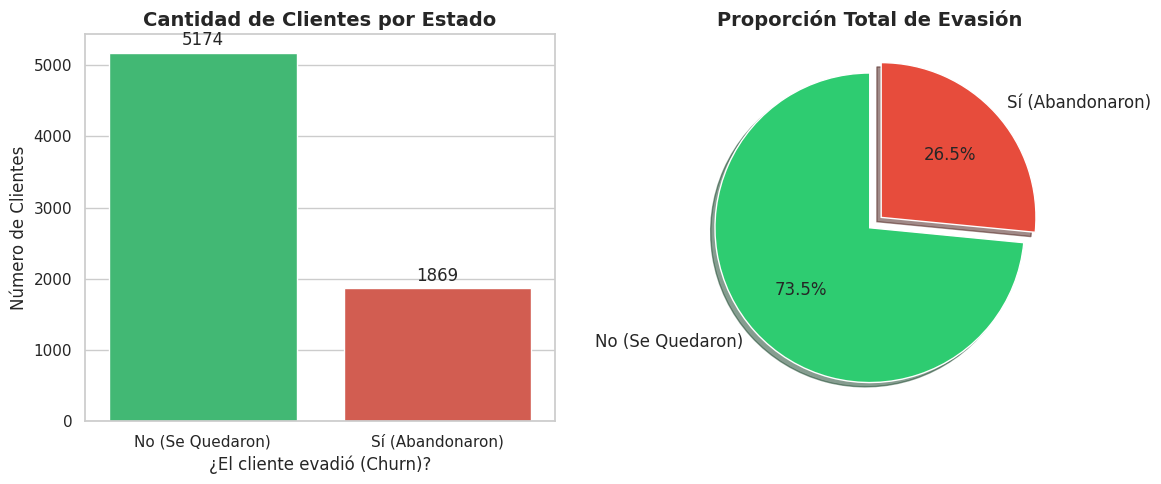

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurarnos de tener los datos con etiquetas legibles
# Como convertiste Churn a 1 y 0 en pasos anteriores, los mapeamos para la gráfica
mapeo_churn = {0: 'No (Se Quedaron)', 1: 'Sí (Abandonaron)'}
df_simplified['Evasion_Etiq'] = df_simplified['Evasion'].map(mapeo_churn)

# 2. Obtener conteos para las gráficas
conteo = df_simplified['Evasion_Etiq'].value_counts()

# 3. Configurar el tamaño y estilo de las gráficas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Barras ---
# Usamos verde para retenidos y rojo para evadidos
# Código moderno (sin advertencias):
sns.barplot(x=conteo.index, y=conteo.values, ax=axes[0], hue=conteo.index, palette=["#2ecc71", "#e74c3c"], legend=False)
axes[0].set_title('Cantidad de Clientes por Estado', fontsize=14, weight='bold')
axes[0].set_ylabel('Número de Clientes', fontsize=12)
axes[0].set_xlabel('¿El cliente evadió (Churn)?', fontsize=12)

# Añadir los números encima de las barras para mayor claridad
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9), textcoords = 'offset points')

# --- Gráfico 2: Pastel (Torta) ---
axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=["#2ecc71", "#e74c3c"], startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Proporción Total de Evasión', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

# (Opcional) Eliminar la columna temporal de etiquetas
df_simplified = df_simplified.drop(columns=['Evasion_Etiq'])

# **Recuento de evasión por variables categóricas**

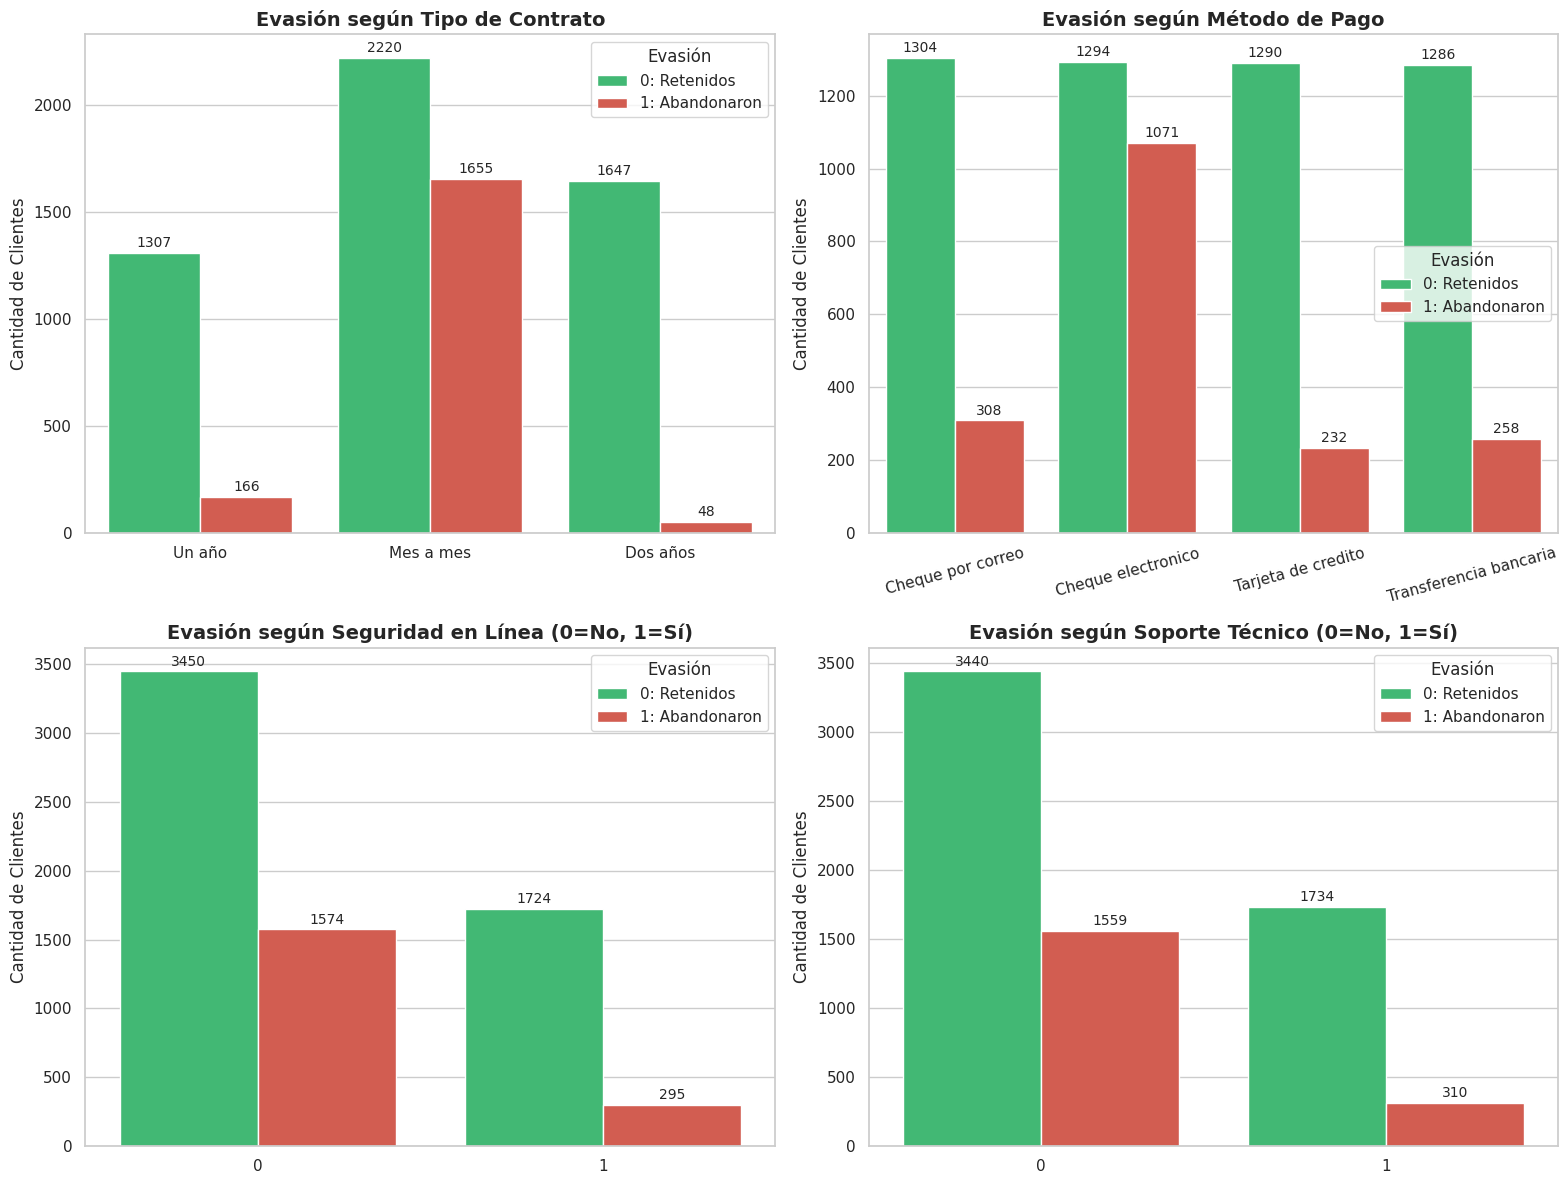

In [77]:
# Configurar el estilo y tamaño del panel de gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Función para evitar repetir código en cada gráfico
def graficar_evasion(columna, ax, titulo):
    # Usar countplot cruzando tu columna con la Evasión (0 y 1)
    sns.countplot(data=df_simplified, x=columna, hue='Evasion', ax=ax, palette=["#2ecc71", "#e74c3c"])

    ax.set_title(titulo, fontsize=14, weight='bold')
    ax.set_ylabel('Cantidad de Clientes', fontsize=12)
    ax.set_xlabel('')

    # Cambiar leyenda de 0 y 1 a texto legible
    ax.legend(title='Evasión', labels=['0: Retenidos', '1: Abandonaron'])

    # Poner los números exactos arriba de cada barra
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0: # Solo imprimir si la barra tiene datos
            ax.annotate(f'{int(altura)}', (p.get_x() + p.get_width() / 2., altura),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 2), textcoords='offset points')

# 1. Gráfico: Evasión vs Contrato
graficar_evasion('Contrato', axes[0, 0], 'Evasión según Tipo de Contrato')

# 2. Gráfico: Evasión vs Método de Pago (rotamos los textos del eje x para que se lean bien)
graficar_evasion('Metodo_Pago', axes[0, 1], 'Evasión según Método de Pago')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Gráfico: Evasión vs Seguridad en Línea
# Recordemos que tus columnas de servicios están en 1 (Sí) y 0 (No)
graficar_evasion('Seguridad_En_Linea', axes[1, 0], 'Evasión según Seguridad en Línea (0=No, 1=Sí)')

# 4. Gráfico: Evasión vs Soporte Técnico
graficar_evasion('Soporte_Tecnico', axes[1, 1], 'Evasión según Soporte Técnico (0=No, 1=Sí)')

# Ajustar los espacios para que no se superpongan
plt.tight_layout()
plt.show()

# Se generaron un panel con 4 gráficos  donde cruzamos **la Evasión(Churn)** con: **Tipo de Contrato**, **Método de Pago**, **Seguridad en Línea** y **Soporte Técnico.**

 Los grandes descubrimientos de tus datos:
El Tipo de Contrato es crítico: ***¡El 42.7% de los clientes con contratos "Mes a mes" abandona la empresa!*** En cambio, la lealtad es altísima en los contratos de "Dos años" (solo el 2.8% de evasión).

El "Cheque electrónico" es una bandera roja: **Los clientes que usan este método de pago tienen una tasa de abandono desproporcionadamente más alta **que aquellos que pagan con tarjeta de crédito o transferencia bancaria.

 Servicios de valor agregado como anclas: Quienes no tienen contratado Soporte Técnico ni Seguridad en Línea representan la inmensa mayoría de las bajas. Ofrecer estos servicios **(quizás gratis por unos meses) podría ser una estrategia clave de retención.**

# **Conteo de evasión por variables numéricas**

¡Este es el paso final de nuestro Análisis Exploratorio de Datos (EDA) y uno de los más poderosos!

Analizar cómo cambian las distribuciones de los números (tiempo y dinero) según si un cliente se queda o se va, suele arrojar insights determinantes para el negocio. Para esto, he creado un panel con Histogramas (para ver cómo se concentran los clientes) y Boxplots (diagramas de caja, ideales para comparar promedios y ver valores atípicos).

(Puedes ver el gráfico resultante en la parte superior de esta conversación).

💡 Los grandes descubrimientos de tus datos numéricos:
La "Zona de Peligro" de los primeros meses (Permanencia_Meses):

Observa el primer histograma: Hay un "pico" gigantesco de color rojo al principio del gráfico. Esto indica que la mayoría de los clientes que abandonan lo hacen en los primeros meses de servicio.

De hecho, la mediana de permanencia de los que abandonan es de apenas 10 meses, frente a los 38 meses de los que se quedan.

El "Impuesto" a la Lealtad (Cargo_Mensual):

En el boxplot de abajo a la derecha, verás que la "caja" roja está más alta que la verde.

Los clientes que abandonan la compañía pagan sistemáticamente facturas más caras (una mediana de $79.65 al mes)

frente a los que se quedan (que pagan unos $64.42 al mes). El precio elevado es un motivador clarísimo de la evasión.

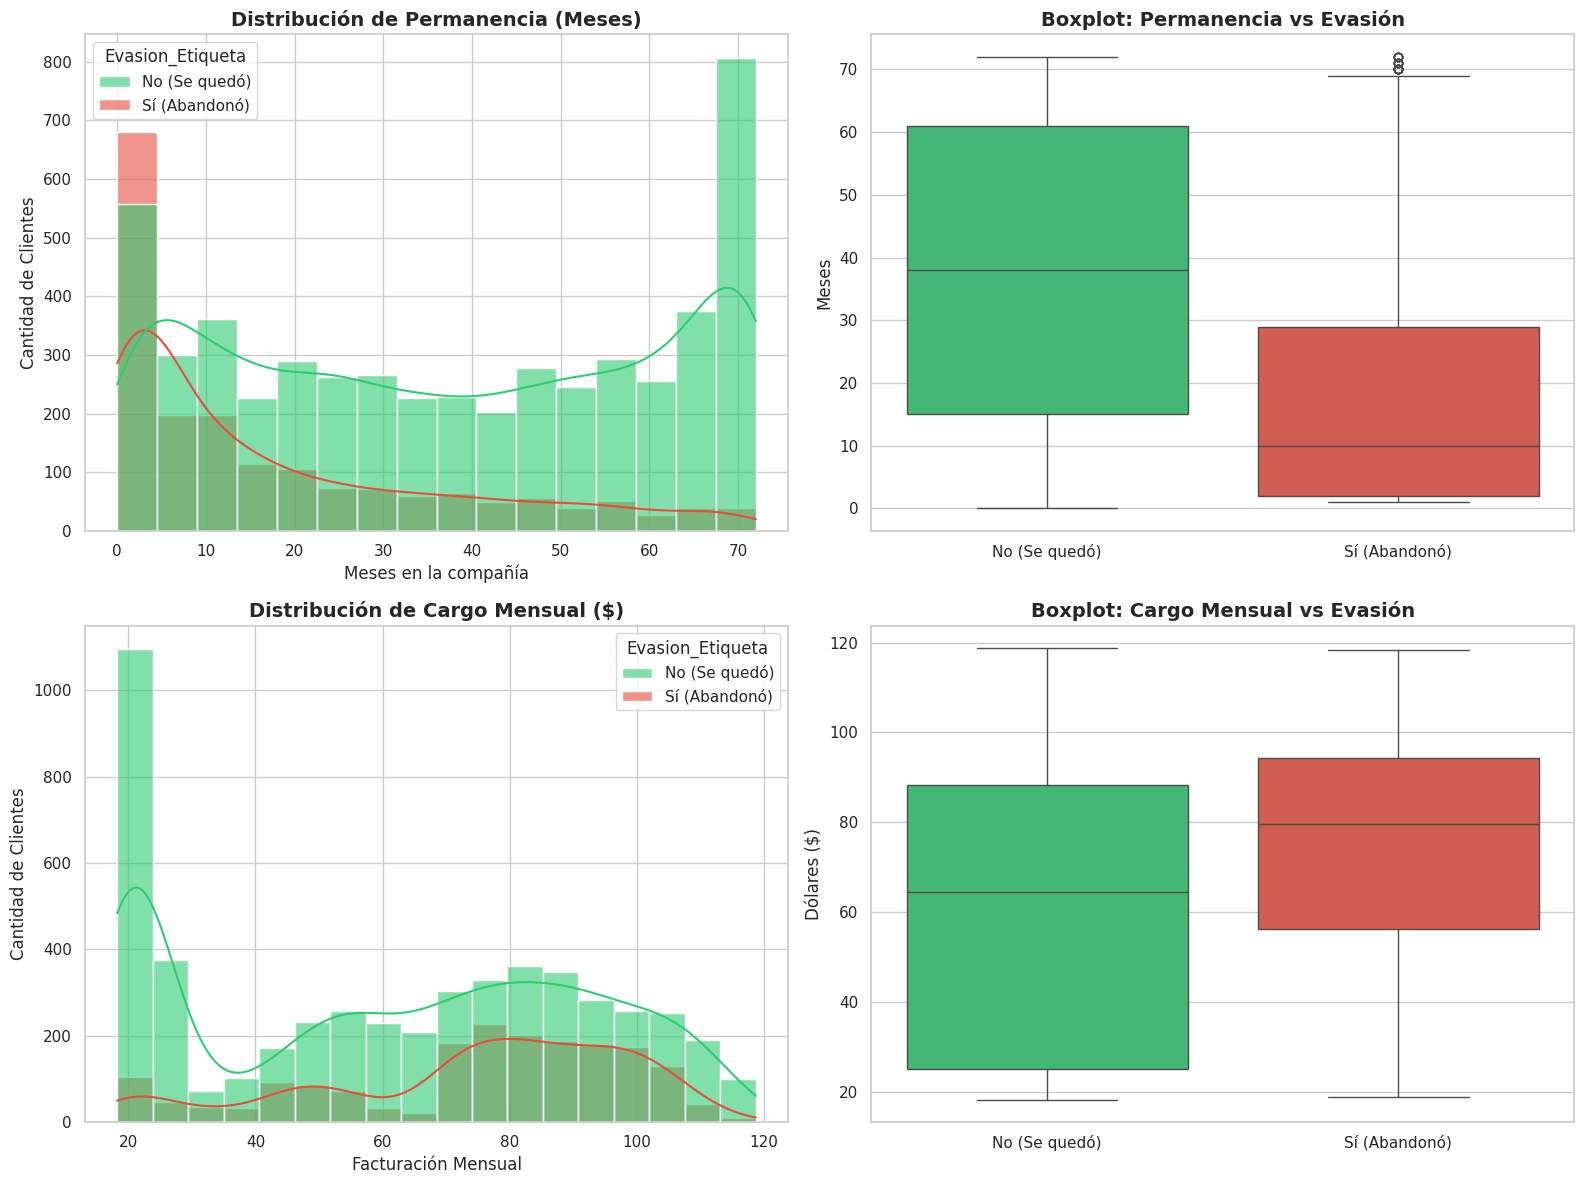

In [78]:
# Configurar el estilo y el tamaño del lienzo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Para facilitar la visualización de la leyenda, mapeamos la columna Evasion momentáneamente
df_plot = df_simplified.copy()
df_plot['Evasion_Etiqueta'] = df_plot['Evasion'].map({0: 'No (Se quedó)', 1: 'Sí (Abandonó)'})

# Definimos los colores: Verde para Retenidos, Rojo para Abandonos
colores = ["#2ecc71", "#e74c3c"]

# ---------------------------------------------------------
# 1. Histograma: Distribución de Permanencia (Meses)
# ---------------------------------------------------------
sns.histplot(data=df_plot, x='Permanencia_Meses', hue='Evasion_Etiqueta',
             kde=True, ax=axes[0, 0], palette=colores, alpha=0.6)
axes[0, 0].set_title('Distribución de Permanencia (Meses)', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Meses en la compañía', fontsize=12)
axes[0, 0].set_ylabel('Cantidad de Clientes', fontsize=12)

# ---------------------------------------------------------
# 2. Boxplot: Permanencia vs Evasión
# ---------------------------------------------------------
sns.boxplot(data=df_plot, x='Evasion_Etiqueta', y='Permanencia_Meses',
            hue='Evasion_Etiqueta', ax=axes[0, 1], palette=colores, legend=False)
axes[0, 1].set_title('Boxplot: Permanencia vs Evasión', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('', fontsize=12)
axes[0, 1].set_ylabel('Meses', fontsize=12)

# ---------------------------------------------------------
# 3. Histograma: Distribución de Cargo Mensual ($)
# ---------------------------------------------------------
sns.histplot(data=df_plot, x='Cargo_Mensual', hue='Evasion_Etiqueta',
             kde=True, ax=axes[1, 0], palette=colores, alpha=0.6)
axes[1, 0].set_title('Distribución de Cargo Mensual ($)', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Facturación Mensual', fontsize=12)
axes[1, 0].set_ylabel('Cantidad de Clientes', fontsize=12)

# ---------------------------------------------------------
# 4. Boxplot: Cargo Mensual vs Evasión
# ---------------------------------------------------------
sns.boxplot(data=df_plot, x='Evasion_Etiqueta', y='Cargo_Mensual',
            hue='Evasion_Etiqueta', ax=axes[1, 1], palette=colores, legend=False)
axes[1, 1].set_title('Boxplot: Cargo Mensual vs Evasión', fontsize=14, weight='bold')
axes[1, 1].set_xlabel('', fontsize=12)
axes[1, 1].set_ylabel('Dólares ($)', fontsize=12)

plt.tight_layout()
plt.show()

📊 Reporte Final: Análisis de Evasión de Clientes (Churn) en TelecomX
# **🔹 1. Introducción**
En la industria de las telecomunicaciones, retener a un cliente existente suele ser mucho más rentable que adquirir uno nuevo. El presente informe documenta el análisis del fenómeno de Evasión (Churn) en la empresa TelecomX. El objetivo principal de este proyecto es identificar los factores clave que impulsan a los clientes a cancelar sus servicios, extraer patrones de comportamiento y proporcionar una base analítica sólida para diseñar estrategias de retención efectivas.

# **🔹 2. Limpieza y Tratamiento de Datos**
Para garantizar la calidad y confiabilidad del análisis, los datos originales (importados desde un formato jerárquico JSON) fueron sometidos a un riguroso proceso de ingeniería de datos:

Aplanamiento e Integridad: Se transformó la estructura anidada en un formato tabular plano y se eliminaron registros duplicados basados en el ID del cliente.

Tratamiento de Valores Nulos: Se identificaron y eliminaron 224 registros que carecían de información en la variable objetivo (Churn), evitando sesgos futuros.

Transformación de Tipos de Datos: Las variables de facturación se convirtieron a formato numérico continuo, mientras que las variables binarias clave (Evasión, Soporte Técnico, Seguridad en Línea) se transformaron a valores enteros (1 y 0) para prepararlas para el modelado matemático.

Ingeniería de Características (Feature Engineering): Se creó una nueva variable llamada Cuentas_Diarias para evaluar el impacto psicológico del gasto diario en la retención.

Estandarización y Traducción: Se unificaron categorías redundantes (ej. "Sin servicio de internet" a "No") y se tradujo todo el conjunto de datos al español para facilitar su comprensión a nivel de negocio.

# **🔹 3. Análisis Exploratorio de Datos (EDA)**
A través de la visualización de datos, exploramos la relación entre la cancelación del servicio y las diferentes características de los clientes:

Distribución General: Encontramos que el 26.5% de la base de clientes actual ha abandonado la empresa. Esto representa una fuga significativa de capital.

Variables Categóricas: Al analizar los perfiles, descubrimos que el tipo de contrato es el mayor diferenciador. Los clientes con contratos "Mes a mes" tienen una tasa de evasión alarmante (42.7%), mientras que los contratos a "Dos años" tienen una retención casi total. Además, el método de pago por "Cheque electrónico" agrupa la mayor cantidad de cancelaciones.

Variables Numéricas: Los histogramas revelaron una "zona de peligro" temprana: la mayoría de las cancelaciones ocurren durante los primeros 10 meses de permanencia (Permanencia_Meses). Asimismo, los diagramas de caja confirmaron que los clientes que abandonan pagan facturas mensuales considerablemente más altas (mediana de 79.65 USD) que los clientes retenidos (mediana de 64.42 USD).

# **🔹 4. Conclusiones e Insights**
De la exploración profunda de los datos, surgen las siguientes conclusiones clave:

El compromiso a largo plazo es el mejor escudo: La falta de ataduras de los contratos mensuales facilita la rápida salida de los usuarios insatisfechos o sensibles al precio.

El valor percibido importa: Los clientes no solo huyen por pagar más dinero, sino por sentir que no reciben suficiente a cambio. Aquellos que no cuentan con servicios de valor agregado, como Soporte Técnico o Seguridad en Línea, son mucho más propensos a irse.

Fricción en los pagos: El uso de cheques electrónicos está correlacionado con mayores tasas de abandono, posiblemente debido a que requiere una acción manual y consciente del gasto mes a mes, a diferencia de los débitos automáticos.

# **🔹 5. Recomendaciones Estratégicas**

Basándonos en la evidencia de los datos, se proponen las siguientes acciones de negocio para reducir el Churn:

**Incentivar la migración de contratos**: Crear campañas agresivas de descuentos o beneficios exclusivos para que los clientes del plan "Mes a mes" firmen contratos anuales.

**Períodos de prueba de servicios clave**: Ofrecer "Soporte Técnico" y "Seguridad en Línea" de forma gratuita durante los primeros 6 meses. Esto aumentará la percepción de valor durante la "zona de peligro" crítica y fomentará la dependencia del ecosistema.

**Modernizar la facturación**: Implementar incentivos (como un pequeño porcentaje de descuento en la factura) para los usuarios que migren del cheque electrónico al pago automático con tarjeta de crédito, reduciendo así la fricción mensual del pago.